## Experiment 4: Train the GAN on a dataset of images (e.g., MNIST, CIFAR-10) and monitor the generator and discriminator losses.

Epoch 1/15 | G Loss: 3.3148 | D Loss: 0.4736


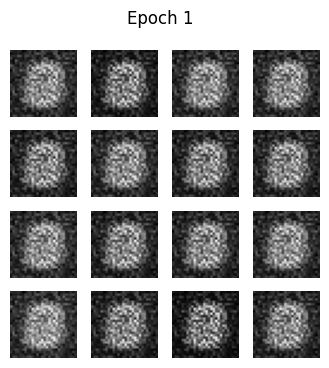

Epoch 2/15 | G Loss: 3.9425 | D Loss: 0.4528


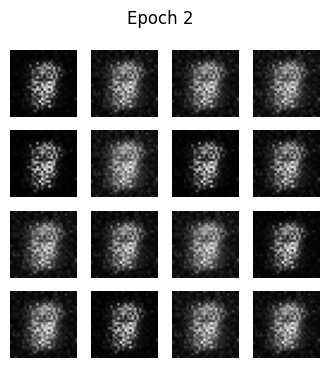

Epoch 3/15 | G Loss: 4.5670 | D Loss: 0.4389


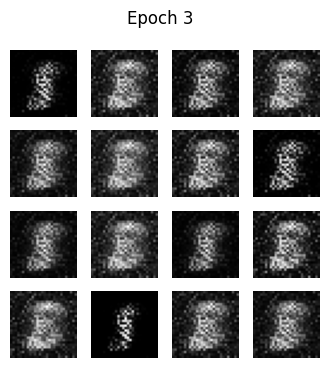

Epoch 4/15 | G Loss: 4.9651 | D Loss: 0.4419


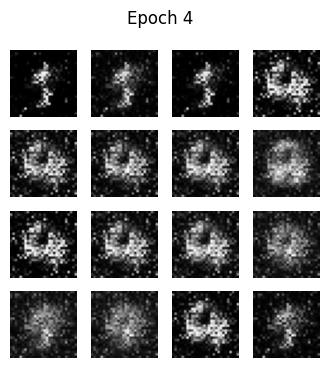

Epoch 5/15 | G Loss: 3.1775 | D Loss: 0.4300


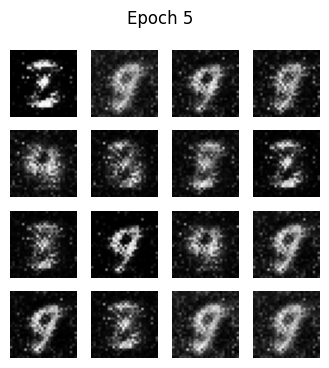

Epoch 6/15 | G Loss: 2.8765 | D Loss: 0.4521


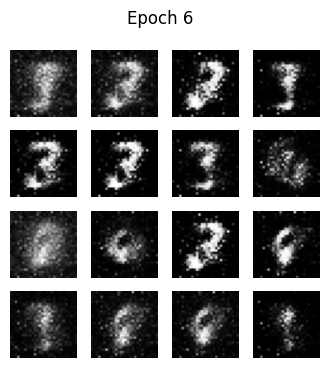

Epoch 7/15 | G Loss: 3.2423 | D Loss: 0.4906


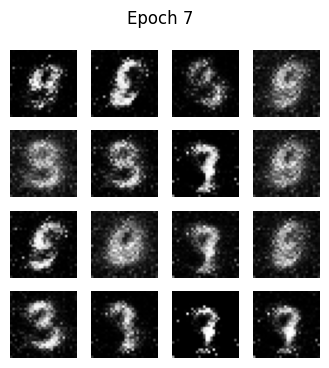

Epoch 8/15 | G Loss: 4.1338 | D Loss: 0.4215


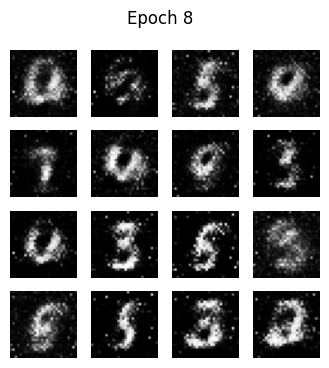

Epoch 9/15 | G Loss: 3.0963 | D Loss: 0.5084


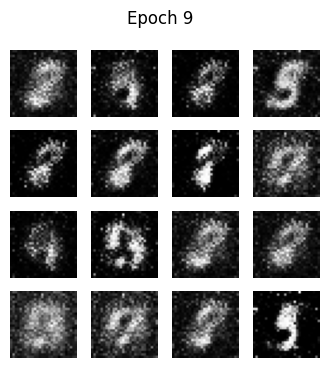

Epoch 10/15 | G Loss: 2.1866 | D Loss: 0.5491


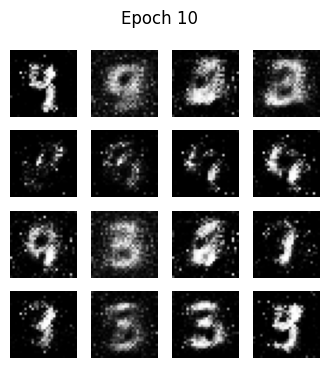

Epoch 11/15 | G Loss: 4.0036 | D Loss: 0.4962


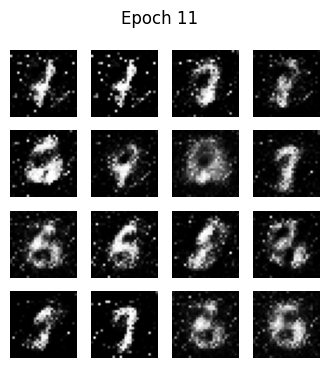

Epoch 12/15 | G Loss: 3.3258 | D Loss: 0.5925


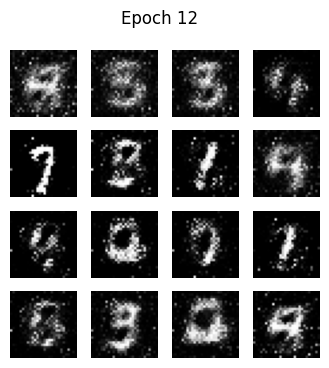

Epoch 13/15 | G Loss: 2.6611 | D Loss: 0.5567


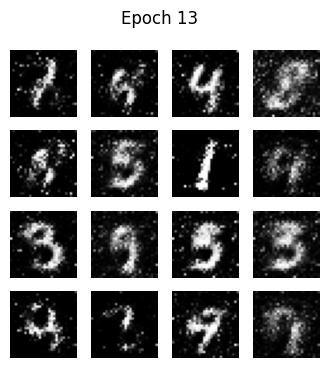

Epoch 14/15 | G Loss: 3.0582 | D Loss: 0.5285


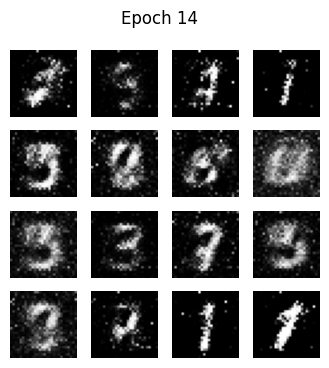

Epoch 15/15 | G Loss: 3.4024 | D Loss: 0.6526


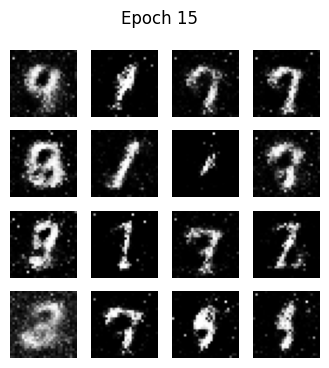

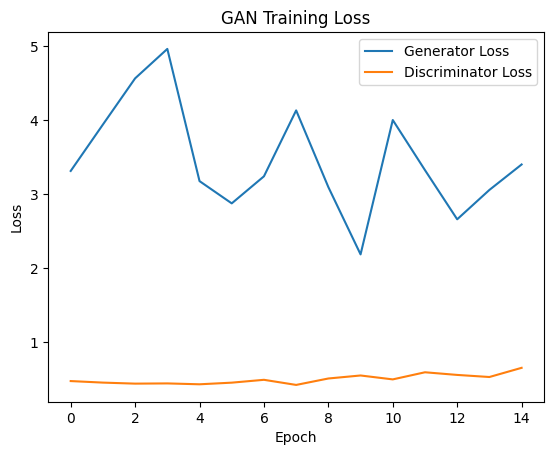

In [2]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#  Data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

#  Hyperparameters
latent_dim = 100
epochs = 15
lr = 0.0002

# Generator
G = nn.Sequential(
    nn.Linear(latent_dim, 256),
    nn.ReLU(),
    nn.Linear(256, 512),
    nn.ReLU(),
    nn.Linear(512, 784),
    nn.Tanh()
).to(device)

# Discriminator
D = nn.Sequential(
    nn.Linear(784, 512),
    nn.LeakyReLU(0.2),
    nn.Linear(512, 256),
    nn.LeakyReLU(0.2),
    nn.Linear(256, 1),
    nn.Sigmoid()
).to(device)

#  Optimizers
opt_G = torch.optim.Adam(G.parameters(), lr=lr)
opt_D = torch.optim.Adam(D.parameters(), lr=lr)

loss_fn = nn.BCELoss()

# Tracking
g_losses, d_losses = [], []

# Training
for epoch in range(epochs):
    for real, _ in loader:
        real = real.view(-1, 784).to(device)
        bs = real.size(0)

        # Label smoothing
        real_labels = torch.ones(bs, 1).to(device) * 0.9
        fake_labels = torch.zeros(bs, 1).to(device)

        # Train Discriminator
        z = torch.randn(bs, latent_dim).to(device)
        fake = G(z).detach()

        loss_D = loss_fn(D(real), real_labels) + loss_fn(D(fake), fake_labels)

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # Train Generator
        z = torch.randn(bs, latent_dim).to(device)
        fake = G(z)

        loss_G = loss_fn(D(fake), real_labels)

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    g_losses.append(loss_G.item())
    d_losses.append(loss_D.item())

    print(f"Epoch {epoch+1}/{epochs} | G Loss: {loss_G.item():.4f} | D Loss: {loss_D.item():.4f}")

    #  Save Sample Images
    with torch.no_grad():
        z = torch.randn(16, latent_dim).to(device)
        samples = G(z).view(-1, 1, 28, 28)

        grid = samples.cpu().numpy()

        plt.figure(figsize=(4,4))
        for i in range(16):
            plt.subplot(4,4,i+1)
            plt.imshow(grid[i][0], cmap='gray')
            plt.axis('off')
        plt.suptitle(f"Epoch {epoch+1}")
        plt.show()

# Plot Loss
plt.plot(g_losses, label="Generator Loss")
plt.plot(d_losses, label="Discriminator Loss")
plt.legend()
plt.title("GAN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()